# Child Mortality Analysis
Predicting Under-5 Mortality Across Countries Using World Development Indicators
Group 5 of "Einführung in maschinelles Lernen" - A Data Science Project.

Ayoub Taychi
Hajar Lasri
Yama Saputra
1.1 Domain Problem
# Research Questions
## 1. Can ML regression models predict under-5 child mortality rates across countries using health, education, income, sanitation, and governance indicators from the WDI?
Justification: Under-5 mortality is a socially relevant and policy-important development outcome that is strontly linked to health, sanitation, income, and demographic conditions.

## 2. Can ML classifiers predict whether a country-year will fall into a high under-5 mortality risk group in the following year?
Justification: High risk is defined as the top 25% next-year under-5 mortality values, which creates a simple and interpretable binary target.

Technical Environment: Python v3.13.13 Importing data project libraries, pandas and scikit learn.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import pycountry

# Stage 1 — Data Preparation

In [19]:
df = pd.read_csv("WB_WDI_WIDEF (1).csv")
print(df.shape)
df.head()
df.info()
print(df.columns.tolist())

(295181, 107)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 295181 entries, 0 to 295180
Columns: 107 entries, STRUCTURE to 2025
dtypes: float64(66), int64(2), object(39)
memory usage: 241.0+ MB
['STRUCTURE', 'STRUCTURE_ID', 'ACTION', 'FREQ', 'REF_AREA', 'INDICATOR', 'SEX', 'AGE', 'URBANISATION', 'UNIT_MEASURE', 'COMP_BREAKDOWN_1', 'COMP_BREAKDOWN_2', 'COMP_BREAKDOWN_3', 'AGG_METHOD', 'UNIT_TYPE', 'DECIMALS', 'DATABASE_ID', 'TIME_FORMAT', 'COMMENT_TS', 'UNIT_MULT', 'DATA_SOURCE', 'OBS_CONF', 'OBS_STATUS', 'FREQ_LABEL', 'REF_AREA_LABEL', 'INDICATOR_LABEL', 'SEX_LABEL', 'AGE_LABEL', 'URBANISATION_LABEL', 'UNIT_MEASURE_LABEL', 'COMP_BREAKDOWN_1_LABEL', 'COMP_BREAKDOWN_2_LABEL', 'COMP_BREAKDOWN_3_LABEL', 'AGG_METHOD_LABEL', 'UNIT_TYPE_LABEL', 'DECIMALS_LABEL', 'DATABASE_ID_LABEL', 'TIME_FORMAT_LABEL', 'UNIT_MULT_LABEL', 'OBS_STATUS_LABEL', 'OBS_CONF_LABEL', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '19

In [21]:
df_prep = df.rename(columns={
    "REF_AREA": "country_code",
    "REF_AREA_LABEL": "country_name",
    "INDICATOR": "indicator_code",
    "INDICATOR_LABEL": "indicator_name"
}).copy()

df_prep[["country_code", "country_name", "indicator_code", "indicator_name"]].head()

,country_code,country_name,indicator_code,indicator_name
0,MNE,Montenegro,WB_WDI_IS_RRS_TOTL_KM,Rail lines (total route-km)
1,MMR,Myanmar,WB_WDI_ST_INT_XPND_CD,"International tourism, expenditures (current US$)"
2,LUX,Luxembourg,WB_WDI_SL_FAM_WORK_FE_ZS,"Contributing family workers, female (% of fema..."
3,NZL,New Zealand,WB_WDI_NY_TAX_NIND_KN,Taxes less subsidies on products (constant LCU)
4,KOR,"Korea, Rep.",WB_WDI_SE_TER_CUAT_ST_FE_ZS,"Educational attainment, at least completed sho..."


In [23]:
year_cols = [col for col in df_prep.columns if col.isdigit()]

print("Number of year columns:", len(year_cols))
print("First 5 years:", year_cols[:5])
print("Last 5 years:", year_cols[-5:])

Number of year columns: 66
First 5 years: ['1960', '1961', '1962', '1963', '1964']
Last 5 years: ['2021', '2022', '2023', '2024', '2025']


In [25]:
countries_table = (
    df_prep[["country_code", "country_name"]]
    .drop_duplicates()
    .sort_values(["country_name", "country_code"])
    .reset_index(drop=True)
)

print("Number of unique entities:", countries_table.shape[0])
countries_table.head(20)

Number of unique entities: 265


,country_code,country_name
0,AFG,Afghanistan
1,ALB,Albania
2,DZA,Algeria
3,ASM,American Samoa
4,AND,Andorra
5,AGO,Angola
6,ATG,Antigua and Barbuda
7,ARB,Arab World
8,ARG,Argentina
9,ARM,Armenia


In [27]:
iso3 = {c.alpha_3 for c in pycountry.countries} | {"XKX"}

countries_only_table = (
    countries_table[countries_table["country_code"].isin(iso3)]
    .copy()
    .sort_values(["country_name", "country_code"])
    .reset_index(drop=True)
)

print("Number of countries only:", countries_only_table.shape[0])
countries_only_table.head(20)

Number of countries only: 216


,country_code,country_name
0,AFG,Afghanistan
1,ALB,Albania
2,DZA,Algeria
3,ASM,American Samoa
4,AND,Andorra
5,AGO,Angola
6,ATG,Antigua and Barbuda
7,ARG,Argentina
8,ARM,Armenia
9,ABW,Aruba


In [29]:
indicators_table = (
    df_prep[["indicator_code", "indicator_name"]]
    .drop_duplicates()
    .sort_values(["indicator_name", "indicator_code"])
    .reset_index(drop=True)
)

print("Number of unique indicators:", indicators_table.shape[0])
indicators_table.head(20)

Number of unique indicators: 1516


,indicator_code,indicator_name
0,WB_WDI_SH_STA_ARIC_ZS,ARI treatment (% of children under 5 taken to ...
1,WB_WDI_EG_CFT_ACCS_ZS,Access to clean fuels and technologies for coo...
2,WB_WDI_EG_CFT_ACCS_RU_ZS,Access to clean fuels and technologies for coo...
3,WB_WDI_EG_CFT_ACCS_UR_ZS,Access to clean fuels and technologies for coo...
4,WB_WDI_EG_ELC_ACCS_ZS,Access to electricity (% of population)
5,WB_WDI_EG_ELC_ACCS_RU_ZS,"Access to electricity, rural (% of rural popul..."
6,WB_WDI_EG_ELC_ACCS_UR_ZS,"Access to electricity, urban (% of urban popul..."
7,WB_WDI_FX_OWN_TOTL_ZS,Account ownership at a financial institution o...
8,WB_WDI_FX_OWN_TOTL_FE_ZS,Account ownership at a financial institution o...
9,WB_WDI_FX_OWN_TOTL_MA_ZS,Account ownership at a financial institution o...


In [ ]:
keywords = [
    "under-5",
    "mortality",
    "gdp per capita",
    "gini",
    "health expenditure",
    "physicians",
    "immunization",
    "water",
    "sanitation",
    "electricity",
    "primary completion",
    "literacy",
    "rule of law",
    "government effectiveness",
    "fertility",
    "urban population",
    "population ages 0-14",
    "life expectancy"
]

for kw in keywords:
    print(f"\n========== {kw.upper()} ==========")
    display(
        indicators_table[
            indicators_table["indicator_name"].str.contains(kw, case=False, na=False)
        ].head(20)
    )

In [31]:
candidate_indicator_dict = {
    "u5mr": "WB_WDI_SH_DYN_MORT",

    "gdp_pc_constant_2015_usd": "WB_WDI_NY_GDP_PCAP_KD",
    "gdp_pc_ppp_current": "WB_WDI_NY_GDP_PCAP_PP_CD",
    "gini": "WB_WDI_SI_POV_GINI",

    "health_exp_pct_gdp": "WB_WDI_SH_XPD_CHEX_GD_ZS",
    "physicians_per_1000": "WB_WDI_SH_MED_PHYS_ZS",
    "dpt": "WB_WDI_SH_IMM_IDPT",
    "measles": "WB_WDI_SH_IMM_MEAS",
    "life_expectancy": "WB_WDI_SP_DYN_LE00_IN",
    "neonatal_mortality": "WB_WDI_SH_DYN_NMRT",

    "water_basic": "WB_WDI_SH_H2O_BASW_ZS",
    "water_safe": "WB_WDI_SH_H2O_SMDW_ZS",
    "sanitation_basic": "WB_WDI_SH_STA_BASS_ZS",
    "sanitation_safe": "WB_WDI_SH_STA_SMSS_ZS",
    "electricity": "WB_WDI_EG_ELC_ACCS_ZS",

    "primary_completion": "WB_WDI_SE_PRM_CMPT_ZS",
    "adult_literacy": "WB_WDI_SE_ADT_LITR_ZS",
    "rule_of_law": "WB_WDI_RL_EST",
    "govt_effectiveness": "WB_WDI_GE_EST",

    "fertility": "WB_WDI_SP_DYN_TFRT_IN",
    "urban_pct": "WB_WDI_SP_URB_TOTL_IN_ZS",
    "urban_population_total": "WB_WDI_SP_URB_TOTL",
    "population_total": "WB_WDI_SP_POP_TOTL",
    "pop_0_14_pct": "WB_WDI_SP_POP_0014_TO_ZS",
}

print("Number of candidate indicators:", len(candidate_indicator_dict))
print(list(candidate_indicator_dict.keys()))

Number of candidate indicators: 24
['u5mr', 'gdp_pc_constant_2015_usd', 'gdp_pc_ppp_current', 'gini', 'health_exp_pct_gdp', 'physicians_per_1000', 'dpt', 'measles', 'life_expectancy', 'neonatal_mortality', 'water_basic', 'water_safe', 'sanitation_basic', 'sanitation_safe', 'electricity', 'primary_completion', 'adult_literacy', 'rule_of_law', 'govt_effectiveness', 'fertility', 'urban_pct', 'urban_population_total', 'population_total', 'pop_0_14_pct']


In [33]:
candidate_indicators_table = pd.DataFrame({
    "new_name": list(candidate_indicator_dict.keys()),
    "indicator_code": list(candidate_indicator_dict.values())
})

candidate_indicators_table = candidate_indicators_table.merge(
    indicators_table,
    on="indicator_code",
    how="left"
).sort_values("new_name").reset_index(drop=True)

candidate_indicators_table

,new_name,indicator_code,indicator_name
0,adult_literacy,WB_WDI_SE_ADT_LITR_ZS,"Literacy rate, adult total (% of people ages 1..."
1,dpt,WB_WDI_SH_IMM_IDPT,"Immunization, DPT (% of children ages 12-23 mo..."
2,electricity,WB_WDI_EG_ELC_ACCS_ZS,Access to electricity (% of population)
3,fertility,WB_WDI_SP_DYN_TFRT_IN,"Fertility rate, total (births per woman)"
4,gdp_pc_constant_2015_usd,WB_WDI_NY_GDP_PCAP_KD,GDP per capita (constant 2015 US$)
5,gdp_pc_ppp_current,WB_WDI_NY_GDP_PCAP_PP_CD,"GDP per capita, PPP (current international $)"
6,gini,WB_WDI_SI_POV_GINI,Gini index
7,govt_effectiveness,WB_WDI_GE_EST,Government Effectiveness: Estimate
8,health_exp_pct_gdp,WB_WDI_SH_XPD_CHEX_GD_ZS,Current health expenditure (% of GDP)
9,life_expectancy,WB_WDI_SP_DYN_LE00_IN,"Life expectancy at birth, total (years)"


In [35]:
keep_cols = ["country_code", "country_name", "indicator_code", "indicator_name"] + year_cols
df_stage1 = df_prep[keep_cols].copy()

print("Initial stage1 shape:", df_stage1.shape)
df_stage1.head(10)

Initial stage1 shape: (295181, 70)


,country_code,country_name,indicator_code,indicator_name,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,MNE,Montenegro,WB_WDI_IS_RRS_TOTL_KM,Rail lines (total route-km),NaN,NaN,NaN,NaN,NaN,NaN,...,2.490000e+02,2.490000e+02,2.490000e+02,2.500000e+02,NaN,NaN,NaN,NaN,NaN,NaN
1,MMR,Myanmar,WB_WDI_ST_INT_XPND_CD,"International tourism, expenditures (current US$)",NaN,NaN,NaN,NaN,NaN,NaN,...,2.010000e+08,1.360000e+08,1.180000e+08,2.140000e+08,NaN,NaN,NaN,NaN,NaN,NaN
2,LUX,Luxembourg,WB_WDI_SL_FAM_WORK_FE_ZS,"Contributing family workers, female (% of fema...",NaN,NaN,NaN,NaN,NaN,NaN,...,1.394918e+00,9.868241e-01,8.426004e-01,1.478158e+00,1.654600e+00,1.686016e+00,2.180262e+00,1.688659e+00,1.988782,1.98045
3,NZL,New Zealand,WB_WDI_NY_TAX_NIND_KN,Taxes less subsidies on products (constant LCU),NaN,NaN,NaN,NaN,NaN,NaN,...,2.453566e+10,2.549904e+10,2.645277e+10,2.701978e+10,2.642800e+10,2.788406e+10,2.952042e+10,2.952592e+10,NaN,NaN
4,KOR,"Korea, Rep.",WB_WDI_SE_TER_CUAT_ST_FE_ZS,"Educational attainment, at least completed sho...",NaN,NaN,NaN,NaN,NaN,NaN,...,3.735632e+01,3.831938e+01,3.941874e+01,4.034009e+01,4.086267e+01,4.145240e+01,4.228944e+01,4.345861e+01,44.547663,NaN
5,GNB,Guinea-Bissau,WB_WDI_SH_DTH_0509,Number of deaths ages 5-9 years,NaN,NaN,NaN,NaN,NaN,NaN,...,4.740000e+02,4.530000e+02,4.350000e+02,4.210000e+02,4.080000e+02,3.960000e+02,3.820000e+02,3.710000e+02,NaN,NaN
6,LBR,Liberia,WB_WDI_DC_DAC_LUXL_CD,"Net bilateral aid flows from DAC donors, Luxem...",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,DNK,Denmark,WB_WDI_EN_GHG_CH4_FE_MT_CE_AR5,Methane (CH4) emissions from Fugitive Emission...,NaN,NaN,NaN,NaN,NaN,NaN,...,4.455000e-01,4.596000e-01,4.609000e-01,4.523000e-01,4.321000e-01,4.486000e-01,4.683000e-01,4.827000e-01,0.504500,NaN
8,SMR,San Marino,WB_WDI_BM_GSR_TOTL_CD,"Imports of goods, services and primary income ...",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2.540829e+09,2.800577e+09,2.631837e+09,2.470865e+09,3.238489e+09,3.446677e+09,3.470362e+09,NaN,NaN
9,SMR,San Marino,WB_WDI_NY_GDP_MKTP_KD_ZG,GDP growth (annual %),NaN,NaN,NaN,NaN,NaN,NaN,...,2.344406e+00,2.582655e-01,1.493905e+00,2.065685e+00,-6.647911e+00,1.389779e+01,7.898441e+00,4.019349e-01,NaN,NaN


In [37]:
country_codes_only = set(countries_only_table["country_code"])

df_stage1 = df_stage1[df_stage1["country_code"].isin(country_codes_only)].copy()

print("Shape after countries-only filter:", df_stage1.shape)
print("Unique countries:", df_stage1["country_code"].nunique())

Shape after countries-only filter: (251650, 70)
Unique countries: 216


In [39]:
df_stage1 = df_stage1[df_stage1["indicator_code"].isin(candidate_indicator_dict.values())].copy()

print("Shape after candidate-indicator filter:", df_stage1.shape)
print("Unique indicators kept:", df_stage1["indicator_code"].nunique())
sorted(df_stage1["indicator_code"].unique())

Shape after candidate-indicator filter: (4779, 70)
Unique indicators kept: 24


['WB_WDI_EG_ELC_ACCS_ZS',
 'WB_WDI_GE_EST',
 'WB_WDI_NY_GDP_PCAP_KD',
 'WB_WDI_NY_GDP_PCAP_PP_CD',
 'WB_WDI_RL_EST',
 'WB_WDI_SE_ADT_LITR_ZS',
 'WB_WDI_SE_PRM_CMPT_ZS',
 'WB_WDI_SH_DYN_MORT',
 'WB_WDI_SH_DYN_NMRT',
 'WB_WDI_SH_H2O_BASW_ZS',
 'WB_WDI_SH_H2O_SMDW_ZS',
 'WB_WDI_SH_IMM_IDPT',
 'WB_WDI_SH_IMM_MEAS',
 'WB_WDI_SH_MED_PHYS_ZS',
 'WB_WDI_SH_STA_BASS_ZS',
 'WB_WDI_SH_STA_SMSS_ZS',
 'WB_WDI_SH_XPD_CHEX_GD_ZS',
 'WB_WDI_SI_POV_GINI',
 'WB_WDI_SP_DYN_LE00_IN',
 'WB_WDI_SP_DYN_TFRT_IN',
 'WB_WDI_SP_POP_0014_TO_ZS',
 'WB_WDI_SP_POP_TOTL',
 'WB_WDI_SP_URB_TOTL',
 'WB_WDI_SP_URB_TOTL_IN_ZS']

In [41]:
inverse_indicator_map = {v: k for k, v in candidate_indicator_dict.items()}

print("Inverse map size:", len(inverse_indicator_map))
list(inverse_indicator_map.items())[:5]

Inverse map size: 24


[('WB_WDI_SH_DYN_MORT', 'u5mr'),
 ('WB_WDI_NY_GDP_PCAP_KD', 'gdp_pc_constant_2015_usd'),
 ('WB_WDI_NY_GDP_PCAP_PP_CD', 'gdp_pc_ppp_current'),
 ('WB_WDI_SI_POV_GINI', 'gini'),
 ('WB_WDI_SH_XPD_CHEX_GD_ZS', 'health_exp_pct_gdp')]

In [43]:
long_df = df_stage1.melt(
    id_vars=["country_code", "country_name", "indicator_code", "indicator_name"],
    value_vars=year_cols,
    var_name="year",
    value_name="value"
)

long_df["year"] = long_df["year"].astype(int)

print("long_df shape:", long_df.shape)
long_df.head(10)

long_df shape: (315414, 6)


,country_code,country_name,indicator_code,indicator_name,year,value
0,GMB,"Gambia, The",WB_WDI_NY_GDP_PCAP_PP_CD,"GDP per capita, PPP (current international $)",1960,NaN
1,KAZ,Kazakhstan,WB_WDI_SH_DYN_NMRT,"Mortality rate, neonatal (per 1,000 live births)",1960,NaN
2,PNG,Papua New Guinea,WB_WDI_SH_DYN_NMRT,"Mortality rate, neonatal (per 1,000 live births)",1960,NaN
3,NAM,Namibia,WB_WDI_SH_DYN_MORT,"Mortality rate, under-5 (per 1,000 live births)",1960,NaN
4,ETH,Ethiopia,WB_WDI_SP_DYN_LE00_IN,"Life expectancy at birth, total (years)",1960,39.615
5,TJK,Tajikistan,WB_WDI_NY_GDP_PCAP_KD,GDP per capita (constant 2015 US$),1960,NaN
6,LUX,Luxembourg,WB_WDI_SE_PRM_CMPT_ZS,"Primary completion rate, total (% of relevant ...",1960,NaN
7,COM,Comoros,WB_WDI_SH_XPD_CHEX_GD_ZS,Current health expenditure (% of GDP),1960,NaN
8,KIR,Kiribati,WB_WDI_SP_DYN_LE00_IN,"Life expectancy at birth, total (years)",1960,47.958
9,ZMB,Zambia,WB_WDI_NY_GDP_PCAP_PP_CD,"GDP per capita, PPP (current international $)",1960,NaN


In [45]:
long_df["indicator_short"] = long_df["indicator_code"].map(inverse_indicator_map)

print("Missing short names:", long_df["indicator_short"].isna().sum())

long_df[["indicator_code", "indicator_short"]].drop_duplicates().sort_values("indicator_short").head(30)

Missing short names: 0


,indicator_code,indicator_short
15,WB_WDI_SE_ADT_LITR_ZS,adult_literacy
63,WB_WDI_SH_IMM_IDPT,dpt
14,WB_WDI_EG_ELC_ACCS_ZS,electricity
40,WB_WDI_SP_DYN_TFRT_IN,fertility
5,WB_WDI_NY_GDP_PCAP_KD,gdp_pc_constant_2015_usd
0,WB_WDI_NY_GDP_PCAP_PP_CD,gdp_pc_ppp_current
94,WB_WDI_SI_POV_GINI,gini
10,WB_WDI_GE_EST,govt_effectiveness
7,WB_WDI_SH_XPD_CHEX_GD_ZS,health_exp_pct_gdp
4,WB_WDI_SP_DYN_LE00_IN,life_expectancy


In [47]:
panel_candidate = long_df.pivot_table(
    index=["country_code", "country_name", "year"],
    columns="indicator_short",
    values="value",
    aggfunc="first"
).reset_index()

panel_candidate.columns.name = None

print("panel_candidate shape:", panel_candidate.shape)
panel_candidate.head(10)

panel_candidate shape: (14051, 27)


,country_code,country_name,year,adult_literacy,dpt,electricity,fertility,gdp_pc_constant_2015_usd,gdp_pc_ppp_current,gini,...,population_total,primary_completion,rule_of_law,sanitation_basic,sanitation_safe,u5mr,urban_pct,urban_population_total,water_basic,water_safe
0,ABW,Aruba,1960,NaN,NaN,NaN,4.567,NaN,NaN,NaN,...,54922.0,NaN,NaN,NaN,NaN,NaN,59.023670,32417.0,NaN,NaN
1,ABW,Aruba,1961,NaN,NaN,NaN,4.422,NaN,NaN,NaN,...,55578.0,NaN,NaN,NaN,NaN,NaN,59.072800,32831.0,NaN,NaN
2,ABW,Aruba,1962,NaN,NaN,NaN,4.262,NaN,NaN,NaN,...,56320.0,NaN,NaN,NaN,NaN,NaN,59.212271,33348.0,NaN,NaN
3,ABW,Aruba,1963,NaN,NaN,NaN,4.107,NaN,NaN,NaN,...,57002.0,NaN,NaN,NaN,NaN,NaN,59.432359,33878.0,NaN,NaN
4,ABW,Aruba,1964,NaN,NaN,NaN,3.940,NaN,NaN,NaN,...,57619.0,NaN,NaN,NaN,NaN,NaN,59.723340,34412.0,NaN,NaN
5,ABW,Aruba,1965,NaN,NaN,NaN,3.797,NaN,NaN,NaN,...,58190.0,NaN,NaN,NaN,NaN,NaN,60.075491,34958.0,NaN,NaN
6,ABW,Aruba,1966,NaN,NaN,NaN,3.621,NaN,NaN,NaN,...,58694.0,NaN,NaN,NaN,NaN,NaN,60.479087,35498.0,NaN,NaN
7,ABW,Aruba,1967,NaN,NaN,NaN,3.452,NaN,NaN,NaN,...,58990.0,NaN,NaN,NaN,NaN,NaN,60.924404,35939.0,NaN,NaN
8,ABW,Aruba,1968,NaN,NaN,NaN,3.277,NaN,NaN,NaN,...,59069.0,NaN,NaN,NaN,NaN,NaN,61.401720,36269.0,NaN,NaN
9,ABW,Aruba,1969,NaN,NaN,NaN,3.111,NaN,NaN,NaN,...,59052.0,NaN,NaN,NaN,NaN,NaN,61.901310,36554.0,NaN,NaN


In [49]:
panel_candidate = panel_candidate.sort_values(
    ["country_name", "year"]
).reset_index(drop=True)

panel_candidate.head(15)

,country_code,country_name,year,adult_literacy,dpt,electricity,fertility,gdp_pc_constant_2015_usd,gdp_pc_ppp_current,gini,...,population_total,primary_completion,rule_of_law,sanitation_basic,sanitation_safe,u5mr,urban_pct,urban_population_total,water_basic,water_safe
0,AFG,Afghanistan,1960,NaN,NaN,NaN,7.282,NaN,NaN,NaN,...,9035043.0,NaN,NaN,NaN,NaN,353.2,8.122551,733876.0,NaN,NaN
1,AFG,Afghanistan,1961,NaN,NaN,NaN,7.284,NaN,NaN,NaN,...,9214083.0,NaN,NaN,NaN,NaN,347.6,8.389595,773024.0,NaN,NaN
2,AFG,Afghanistan,1962,NaN,NaN,NaN,7.292,NaN,NaN,NaN,...,9404406.0,NaN,NaN,NaN,NaN,342.3,8.662664,814672.0,NaN,NaN
3,AFG,Afghanistan,1963,NaN,NaN,NaN,7.302,NaN,NaN,NaN,...,9604487.0,NaN,NaN,NaN,NaN,336.8,8.942709,858901.0,NaN,NaN
4,AFG,Afghanistan,1964,NaN,NaN,NaN,7.304,NaN,NaN,NaN,...,9814318.0,NaN,NaN,NaN,NaN,331.7,9.231134,905973.0,NaN,NaN
5,AFG,Afghanistan,1965,NaN,NaN,NaN,7.305,NaN,NaN,NaN,...,10036008.0,NaN,NaN,NaN,NaN,326.5,9.529343,956366.0,NaN,NaN
6,AFG,Afghanistan,1966,NaN,NaN,NaN,7.320,NaN,NaN,NaN,...,10266395.0,NaN,NaN,NaN,NaN,321.5,9.838740,1010084.0,NaN,NaN
7,AFG,Afghanistan,1967,NaN,NaN,NaN,7.339,NaN,NaN,NaN,...,10505959.0,NaN,NaN,NaN,NaN,316.6,10.160728,1067482.0,NaN,NaN
8,AFG,Afghanistan,1968,NaN,NaN,NaN,7.363,NaN,NaN,NaN,...,10756922.0,NaN,NaN,NaN,NaN,311.6,10.496712,1129123.0,NaN,NaN
9,AFG,Afghanistan,1969,NaN,NaN,NaN,7.389,NaN,NaN,NaN,...,11017409.0,NaN,NaN,NaN,NaN,306.4,10.848095,1195179.0,NaN,NaN


In [51]:
df_stage1.to_csv("stage1_filtered_raw.csv", index=False)
long_df.to_csv("stage1_long.csv", index=False)
panel_candidate.to_csv("stage1_panel_candidate_full_horizon.csv", index=False)

print("Stage 1 files saved successfully.")

Stage 1 files saved successfully.


# mark end of Stage 1
The raw WDI data were prepared into a country-year candidate panel by:
- renaming key metadata columns,
- keeping countries only,
- selecting a broader candidate indicator set,
- reshaping the data from wide format to long format,
- and building a country-year panel for the full available time horizon.

No final time restriction has been applied yet. The choice of the final modeling window will be justified in Stage 2 using data quality, missingness, and coverage analysis.

# Stage 2 = Data Cleaning + Data Quality Audit + Early EDA 

In [58]:
dup_count = panel_candidate.duplicated(subset=["country_code", "year"]).sum()

print("Duplicate country-year rows:", dup_count)

Duplicate country-year rows: 0


In [60]:
missing_report = pd.DataFrame({
    "missing_count": panel_candidate.isna().sum(),
    "missing_pct": (panel_candidate.isna().mean() * 100)
}).sort_values("missing_pct", ascending=False)

missing_report

,missing_count,missing_pct
adult_literacy,12944,92.121557
gini,11649,82.905131
sanitation_safe,10482,74.599673
water_safe,10335,73.553484
health_exp_pct_gdp,9489,67.532560
primary_completion,9280,66.045121
govt_effectiveness,9087,64.671554
rule_of_law,8973,63.860223
sanitation_basic,8885,63.233934
water_basic,8842,62.927905


In [72]:
target_coverage_by_year = (
    panel_candidate.groupby("year")["u5mr"]
    .apply(lambda s: s.notna().sum())
    .reset_index(name="u5mr_non_missing_countries")
)

target_coverage_by_year.head(66)

,year,u5mr_non_missing_countries
0,1960,128
1,1961,129
2,1962,131
3,1963,134
4,1964,137
...,...,...
61,2021,196
62,2022,196
63,2023,196
64,2024,0


In [78]:
predictor_cols = [
    "gdp_pc_constant_2015_usd",
    "gdp_pc_ppp_current",
    "gini",
    "health_exp_pct_gdp",
    "physicians_per_1000",
    "dpt",
    "measles",
    "life_expectancy",
    "neonatal_mortality",
    "water_basic",
    "water_safe",
    "sanitation_basic",
    "sanitation_safe",
    "electricity",
    "primary_completion",
    "adult_literacy",
    "rule_of_law",
    "govt_effectiveness",
    "fertility",
    "urban_pct",
    "urban_population_total",
    "population_total",
    "pop_0_14_pct"
]

predictor_coverage_by_year = panel_candidate.groupby("year")[predictor_cols].apply(
    lambda df: df.notna().sum()
)

predictor_coverage_by_year.head(20)

,gdp_pc_constant_2015_usd,gdp_pc_ppp_current,gini,health_exp_pct_gdp,physicians_per_1000,dpt,measles,life_expectancy,neonatal_mortality,water_basic,...,electricity,primary_completion,adult_literacy,rule_of_law,govt_effectiveness,fertility,urban_pct,urban_population_total,population_total,pop_0_14_pct
year,,,,,,,,,,,,,,,,,,,,,
1960,107,0,0,0,136,0,0,214,49,0,...,0,0,0,0,0,215,216,215,215,216
1961,112,0,0,0,18,0,0,215,50,0,...,0,0,0,0,0,214,216,215,215,216
1962,112,0,0,0,16,0,0,215,50,0,...,0,0,0,0,0,215,216,215,215,216
1963,112,0,1,0,16,0,0,214,53,0,...,0,0,0,0,0,214,216,215,215,216
1964,112,0,1,0,16,0,0,214,57,0,...,0,0,0,0,0,215,216,215,215,216
1965,114,0,1,0,108,0,0,214,64,0,...,0,0,0,0,0,215,216,215,215,216
1966,117,0,1,0,19,0,0,215,65,0,...,0,0,0,0,0,215,216,215,215,216
1967,118,0,1,0,17,0,0,215,67,0,...,0,0,0,0,0,215,216,215,215,216
1968,118,0,2,0,17,0,0,215,77,0,...,0,0,0,0,0,215,216,215,215,216


In [84]:
core_candidate_cols = [
    "u5mr",
    "gdp_pc_constant_2015_usd",
    "health_exp_pct_gdp",
    "dpt",
    "measles",
    "water_basic",
    "sanitation_basic",
    "electricity",
    "fertility",
    "urban_pct",
    "pop_0_14_pct"
]

joint_core_by_year = (
    panel_candidate.groupby("year")
    .apply(lambda df: pd.Series({
        "n_countries_total": df["country_code"].nunique(),
        "n_complete_core_rows": df[core_candidate_cols].notna().all(axis=1).sum()
    }))
    .reset_index()
)

joint_core_by_year["complete_core_pct"] = (
    100 * joint_core_by_year["n_complete_core_rows"] / joint_core_by_year["n_countries_total"]
)

joint_core_by_year.head(20)

C:\Users\ayoub\AppData\Local\Temp\ipykernel_14200\470281583.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: pd.Series({


,year,n_countries_total,n_complete_core_rows,complete_core_pct
0,1960,216,0,0.0
1,1961,216,0,0.0
2,1962,216,0,0.0
3,1963,216,0,0.0
4,1964,216,0,0.0
5,1965,216,0,0.0
6,1966,216,0,0.0
7,1967,216,0,0.0
8,1968,216,0,0.0
9,1969,216,0,0.0


In [86]:
joint_core_by_year.tail(20)

,year,n_countries_total,n_complete_core_rows,complete_core_pct
46,2006,216,182,84.259259
47,2007,216,183,84.722222
48,2008,216,184,85.185185
49,2009,216,184,85.185185
50,2010,216,185,85.648148
51,2011,216,186,86.111111
52,2012,216,185,85.648148
53,2013,216,188,87.037037
54,2014,216,188,87.037037
55,2015,216,188,87.037037


In [88]:
print("First year with > 0 complete core rows:",
      joint_core_by_year.loc[joint_core_by_year["n_complete_core_rows"] > 0, "year"].min())

print("First year with >= 50% complete core rows:",
      joint_core_by_year.loc[joint_core_by_year["complete_core_pct"] >= 50, "year"].min())

print("First year with >= 70% complete core rows:",
      joint_core_by_year.loc[joint_core_by_year["complete_core_pct"] >= 70, "year"].min())

print("First year with >= 80% complete core rows:",
      joint_core_by_year.loc[joint_core_by_year["complete_core_pct"] >= 80, "year"].min())

First year with > 0 complete core rows: 2000
First year with >= 50% complete core rows: 2000
First year with >= 70% complete core rows: 2000
First year with >= 80% complete core rows: 2001


In [90]:
joint_core_by_year[
    (joint_core_by_year["year"] >= 1990) &
    (joint_core_by_year["year"] <= 2025)
]

,year,n_countries_total,n_complete_core_rows,complete_core_pct
30,1990,216,0,0.000000
31,1991,216,0,0.000000
32,1992,216,0,0.000000
33,1993,216,0,0.000000
34,1994,216,0,0.000000
35,1995,216,0,0.000000
36,1996,216,0,0.000000
37,1997,216,0,0.000000
38,1998,216,0,0.000000
39,1999,216,0,0.000000


## We explored the full 1960–2025 horizon, but joint completeness for the target and core predictors is effectively zero before 2000. ## From 2000 onward, the candidate panel becomes usable and remains stable through 2023. Therefore, the final modeling window will be restricted to 2000–2023

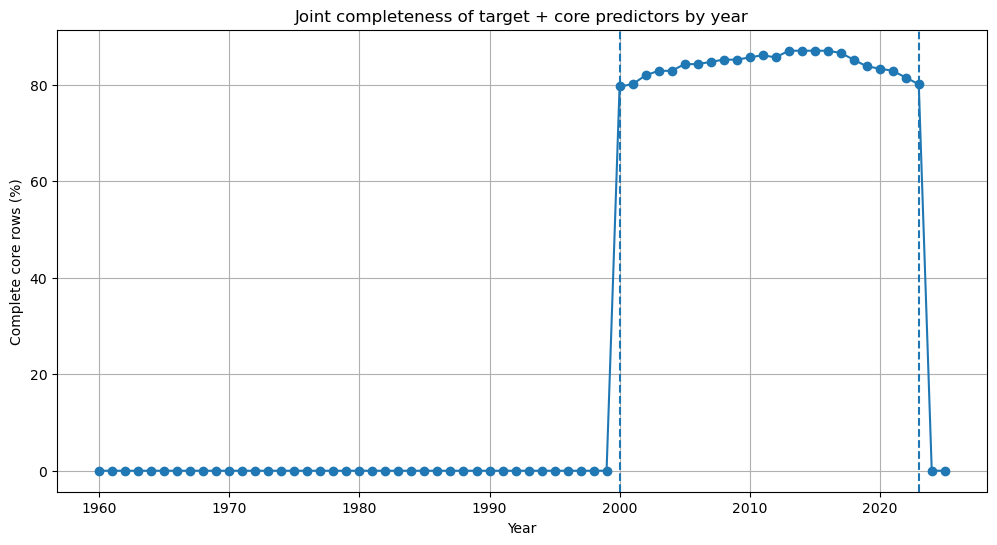

In [95]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(
    joint_core_by_year["year"],
    joint_core_by_year["complete_core_pct"],
    marker="o"
)

plt.axvline(2000, linestyle="--")
plt.axvline(2023, linestyle="--")

plt.title("Joint completeness of target + core predictors by year")
plt.xlabel("Year")
plt.ylabel("Complete core rows (%)")
plt.grid(True)
plt.show()

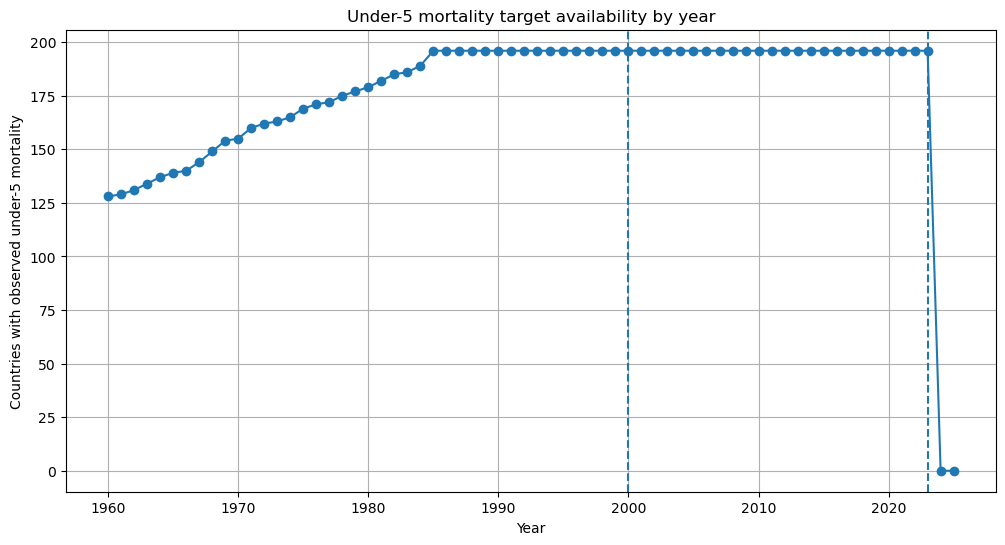

In [97]:
plt.figure(figsize=(12, 6))
plt.plot(
    target_coverage_by_year["year"],
    target_coverage_by_year["u5mr_non_missing_countries"],
    marker="o"
)

plt.axvline(2000, linestyle="--")
plt.axvline(2023, linestyle="--")

plt.title("Under-5 mortality target availability by year")
plt.xlabel("Year")
plt.ylabel("Countries with observed under-5 mortality")
plt.grid(True)
plt.show()

In [99]:
panel_modern = panel_candidate[
    (panel_candidate["year"] >= 2000) &
    (panel_candidate["year"] <= 2023)
].copy()

print("Modern panel shape:", panel_modern.shape)
print("Year range:", panel_modern["year"].min(), "to", panel_modern["year"].max())
print("Countries:", panel_modern["country_code"].nunique())

Modern panel shape: (5184, 27)
Year range: 2000 to 2023
Countries: 216


In [101]:
modern_missing_report = pd.DataFrame({
    "missing_count": panel_modern.isna().sum(),
    "missing_pct": panel_modern.isna().mean() * 100
}).sort_values("missing_pct", ascending=False)

modern_missing_report

,missing_count,missing_pct
adult_literacy,4298,82.908951
gini,3363,64.872685
physicians_per_1000,2326,44.868827
primary_completion,1986,38.310185
sanitation_safe,1756,33.873457
water_safe,1616,31.172840
health_exp_pct_gdp,644,12.422840
govt_effectiveness,582,11.226852
measles,571,11.014660
dpt,571,11.014660


In [103]:
feature_cols_for_audit = [
    "u5mr",
    "gdp_pc_constant_2015_usd",
    "gdp_pc_ppp_current",
    "gini",
    "health_exp_pct_gdp",
    "physicians_per_1000",
    "dpt",
    "measles",
    "life_expectancy",
    "neonatal_mortality",
    "water_basic",
    "water_safe",
    "sanitation_basic",
    "sanitation_safe",
    "electricity",
    "primary_completion",
    "adult_literacy",
    "rule_of_law",
    "govt_effectiveness",
    "fertility",
    "urban_pct",
    "urban_population_total",
    "population_total",
    "pop_0_14_pct"
]

variation_report = pd.DataFrame({
    "non_missing_count": panel_modern[feature_cols_for_audit].notna().sum(),
    "missing_pct": panel_modern[feature_cols_for_audit].isna().mean() * 100,
    "n_unique": panel_modern[feature_cols_for_audit].nunique(dropna=True),
    "std": panel_modern[feature_cols_for_audit].std(),
    "min": panel_modern[feature_cols_for_audit].min(),
    "median": panel_modern[feature_cols_for_audit].median(),
    "max": panel_modern[feature_cols_for_audit].max()
}).sort_values(["missing_pct", "std"], ascending=[True, False])

variation_report

,non_missing_count,missing_pct,n_unique,std,min,median,max
population_total,5184,0.000000,5178,1.303534e+08,9544.000000,5.811484e+06,1.438070e+09
urban_population_total,5184,0.000000,5172,6.158918e+07,4344.000000,3.083875e+06,9.244403e+08
urban_pct,5184,0.000000,4896,2.407669e+01,8.043814,6.078262e+01,1.000000e+02
pop_0_14_pct,5184,0.000000,5184,1.066572e+01,10.699025,2.720830e+01,5.024029e+01
life_expectancy,5184,0.000000,4812,8.785180e+00,14.665000,7.256585e+01,8.637200e+01
fertility,5184,0.000000,2783,1.475667e+00,0.586000,2.284500e+00,7.829000e+00
electricity,5111,1.408179,859,2.884439e+01,0.800000,9.900000e+01,1.000000e+02
water_basic,5007,3.414352,4406,1.765167e+01,18.759061,9.516375e+01,1.000000e+02
sanitation_basic,4973,4.070216,4604,2.915760e+01,2.965766,8.881793e+01,1.000000e+02
gdp_pc_constant_2015_usd,4944,4.629630,4944,2.265881e+04,233.032393,5.637653e+03,2.258842e+05


In [105]:
feature_decision_table = pd.DataFrame({
    "feature": [
        "gdp_pc_constant_2015_usd",
        "health_exp_pct_gdp",
        "dpt",
        "measles",
        "water_basic",
        "sanitation_basic",
        "electricity",
        "fertility",
        "urban_pct",
        "pop_0_14_pct",

        "gdp_pc_ppp_current",
        "physicians_per_1000",
        "primary_completion",
        "rule_of_law",
        "govt_effectiveness",
        "water_safe",
        "sanitation_safe",

        "gini",
        "adult_literacy",
        "life_expectancy",
        "neonatal_mortality",
        "population_total",
        "urban_population_total"
    ],
    "proposed_role": [
        "core_main",
        "core_main",
        "core_main",
        "core_main",
        "core_main",
        "core_main",
        "core_main",
        "core_main",
        "core_main",
        "core_main",

        "extended",
        "extended",
        "extended",
        "extended",
        "extended",
        "extended",
        "extended",

        "exclude_main",
        "exclude_main",
        "exclude_main",
        "exclude_main",
        "exclude_main",
        "exclude_main"
    ],
    "reason": [
        "strong coverage and conceptually central",
        "strong coverage and conceptually central",
        "strong coverage and conceptually central",
        "strong coverage and conceptually central",
        "strong coverage and conceptually central",
        "strong coverage and conceptually central",
        "strong coverage and conceptually central",
        "strong coverage and conceptually central",
        "strong coverage and conceptually central",
        "strong coverage and conceptually central",

        "usable but more optional / redundant",
        "moderate missingness",
        "moderate missingness",
        "moderate missingness, governance extension",
        "moderate missingness, governance extension",
        "moderate missingness, optional stricter access metric",
        "moderate missingness, optional stricter access metric",

        "too much missingness",
        "too much missingness",
        "too close to target conceptually",
        "too close to target conceptually",
        "size variable, not main substantive signal",
        "size variable, not main substantive signal"
    ]
})

feature_decision_table = feature_decision_table.merge(
    variation_report[["missing_pct", "n_unique", "std"]],
    left_on="feature",
    right_index=True,
    how="left"
).sort_values(["proposed_role", "missing_pct"])

feature_decision_table

,feature,proposed_role,reason,missing_pct,n_unique,std
7,fertility,core_main,strong coverage and conceptually central,0.000000,2783,1.475667e+00
8,urban_pct,core_main,strong coverage and conceptually central,0.000000,4896,2.407669e+01
9,pop_0_14_pct,core_main,strong coverage and conceptually central,0.000000,5184,1.066572e+01
6,electricity,core_main,strong coverage and conceptually central,1.408179,859,2.884439e+01
4,water_basic,core_main,strong coverage and conceptually central,3.414352,4406,1.765167e+01
5,sanitation_basic,core_main,strong coverage and conceptually central,4.070216,4604,2.915760e+01
0,gdp_pc_constant_2015_usd,core_main,strong coverage and conceptually central,4.629630,4944,2.265881e+04
2,dpt,core_main,strong coverage and conceptually central,11.014660,78,1.457252e+01
3,measles,core_main,strong coverage and conceptually central,11.014660,80,1.491352e+01
1,health_exp_pct_gdp,core_main,strong coverage and conceptually central,12.422840,4540,2.863431e+00


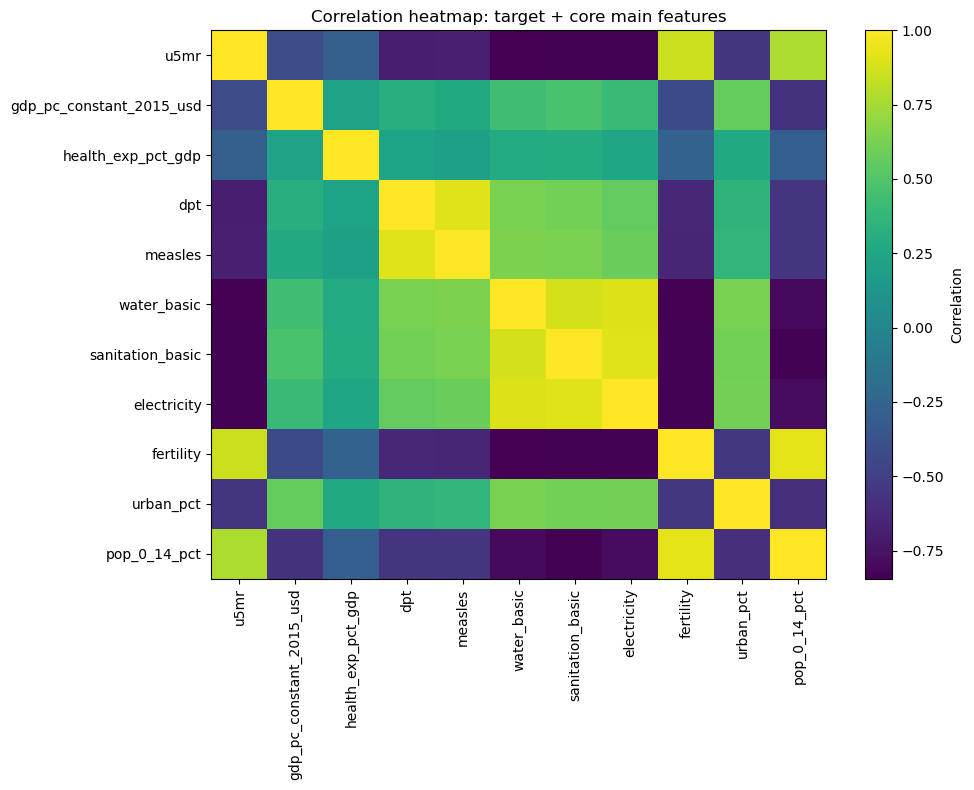

In [107]:
core_plus_target = [
    "u5mr",
    "gdp_pc_constant_2015_usd",
    "health_exp_pct_gdp",
    "dpt",
    "measles",
    "water_basic",
    "sanitation_basic",
    "electricity",
    "fertility",
    "urban_pct",
    "pop_0_14_pct"
]

corr_core = panel_modern[core_plus_target].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_core, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(range(len(corr_core.columns)), corr_core.columns, rotation=90)
plt.yticks(range(len(corr_core.index)), corr_core.index)

plt.title("Correlation heatmap: target + core main features")
plt.tight_layout()
plt.show()

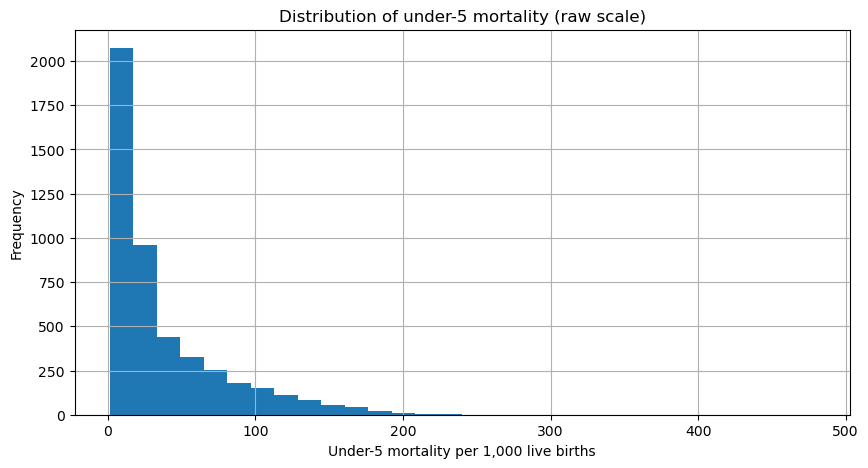

In [109]:
plt.figure(figsize=(10, 5))
plt.hist(panel_modern["u5mr"].dropna(), bins=30)

plt.title("Distribution of under-5 mortality (raw scale)")
plt.xlabel("Under-5 mortality per 1,000 live births")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

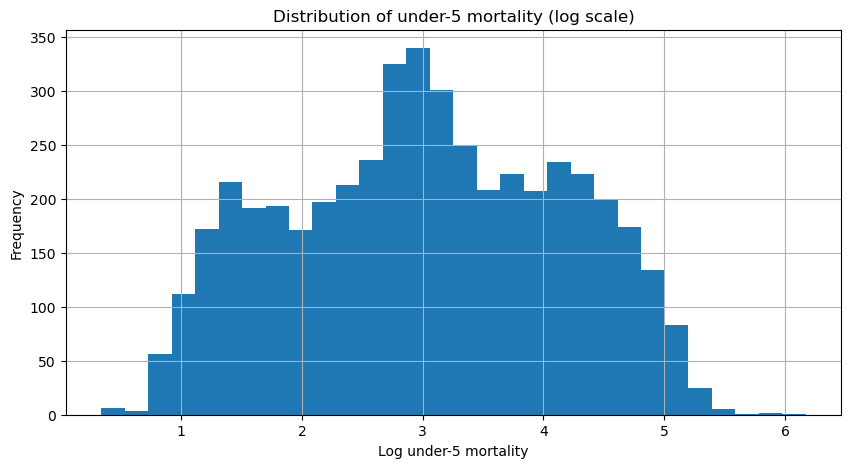

In [111]:
panel_modern["log_u5mr_temp"] = np.log(panel_modern["u5mr"])

plt.figure(figsize=(10, 5))
plt.hist(panel_modern["log_u5mr_temp"].dropna(), bins=30)

plt.title("Distribution of under-5 mortality (log scale)")
plt.xlabel("Log under-5 mortality")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

In [114]:
core_main_features = [
    "gdp_pc_constant_2015_usd",
    "health_exp_pct_gdp",
    "dpt",
    "measles",
    "water_basic",
    "sanitation_basic",
    "electricity",
    "fertility",
    "urban_pct",
    "pop_0_14_pct"
]

country_quality = (
    panel_modern.groupby(["country_code", "country_name"])
    .apply(lambda df: pd.Series({
        "total_years_2000_2023": df["year"].nunique(),
        "u5mr_observed_years": df["u5mr"].notna().sum(),
        "u5mr_missing_years": df["u5mr"].isna().sum(),
        "complete_core_years": df[["u5mr"] + core_main_features].notna().all(axis=1).sum()
    }))
    .reset_index()
)

country_quality["u5mr_coverage_pct"] = 100 * country_quality["u5mr_observed_years"] / country_quality["total_years_2000_2023"]
country_quality["complete_core_pct"] = 100 * country_quality["complete_core_years"] / country_quality["total_years_2000_2023"]

country_quality = country_quality.sort_values(
    ["complete_core_years", "u5mr_observed_years", "country_name"],
    ascending=[True, True, True]
).reset_index(drop=True)

country_quality.head(30)

C:\Users\ayoub\AppData\Local\Temp\ipykernel_14200\724112389.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: pd.Series({


,country_code,country_name,total_years_2000_2023,u5mr_observed_years,u5mr_missing_years,complete_core_years,u5mr_coverage_pct,complete_core_pct
0,ASM,American Samoa,24,0,24,0,0.0,0.000000
1,ABW,Aruba,24,0,24,0,0.0,0.000000
2,BMU,Bermuda,24,0,24,0,0.0,0.000000
3,CYM,Cayman Islands,24,0,24,0,0.0,0.000000
4,CUW,Curaçao,24,0,24,0,0.0,0.000000
5,FRO,Faroe Islands,24,0,24,0,0.0,0.000000
6,PYF,French Polynesia,24,0,24,0,0.0,0.000000
7,GIB,Gibraltar,24,0,24,0,0.0,0.000000
8,GRL,Greenland,24,0,24,0,0.0,0.000000
9,GUM,Guam,24,0,24,0,0.0,0.000000


In [116]:
country_quality.sort_values(
    ["complete_core_years", "u5mr_observed_years"],
    ascending=[False, False]
).head(30)

,country_code,country_name,total_years_2000_2023,u5mr_observed_years,u5mr_missing_years,complete_core_years,u5mr_coverage_pct,complete_core_pct
61,ALB,Albania,24,24,0,24,100.0,100.0
62,DZA,Algeria,24,24,0,24,100.0,100.0
63,AND,Andorra,24,24,0,24,100.0,100.0
64,ATG,Antigua and Barbuda,24,24,0,24,100.0,100.0
65,ARM,Armenia,24,24,0,24,100.0,100.0
66,AUS,Australia,24,24,0,24,100.0,100.0
67,AUT,Austria,24,24,0,24,100.0,100.0
68,AZE,Azerbaijan,24,24,0,24,100.0,100.0
69,BHR,Bahrain,24,24,0,24,100.0,100.0
70,BGD,Bangladesh,24,24,0,24,100.0,100.0


In [118]:
country_quality[country_quality["complete_core_years"] < 10]

,country_code,country_name,total_years_2000_2023,u5mr_observed_years,u5mr_missing_years,complete_core_years,u5mr_coverage_pct,complete_core_pct
0,ASM,American Samoa,24,0,24,0,0.0,0.0
1,ABW,Aruba,24,0,24,0,0.0,0.0
2,BMU,Bermuda,24,0,24,0,0.0,0.0
3,CYM,Cayman Islands,24,0,24,0,0.0,0.0
4,CUW,Curaçao,24,0,24,0,0.0,0.0
5,FRO,Faroe Islands,24,0,24,0,0.0,0.0
6,PYF,French Polynesia,24,0,24,0,0.0,0.0
7,GIB,Gibraltar,24,0,24,0,0.0,0.0
8,GRL,Greenland,24,0,24,0,0.0,0.0
9,GUM,Guam,24,0,24,0,0.0,0.0


In [120]:
country_quality[country_quality["complete_core_years"] == 24]

,country_code,country_name,total_years_2000_2023,u5mr_observed_years,u5mr_missing_years,complete_core_years,u5mr_coverage_pct,complete_core_pct
61,ALB,Albania,24,24,0,24,100.0,100.0
62,DZA,Algeria,24,24,0,24,100.0,100.0
63,AND,Andorra,24,24,0,24,100.0,100.0
64,ATG,Antigua and Barbuda,24,24,0,24,100.0,100.0
65,ARM,Armenia,24,24,0,24,100.0,100.0
...,...,...,...,...,...,...,...,...
211,UZB,Uzbekistan,24,24,0,24,100.0,100.0
212,VUT,Vanuatu,24,24,0,24,100.0,100.0
213,VNM,Vietnam,24,24,0,24,100.0,100.0
214,PSE,West Bank and Gaza,24,24,0,24,100.0,100.0


---

#  End of Stage 2 — Data Cleaning, Data Quality Audit, and Early EDA

Stage 2 examined the quality and usability of the prepared country-year candidate panel.

## Completed in Stage 2
- checked duplicate country-year rows
- assessed missingness across variables
- evaluated target availability over time
- evaluated predictor coverage over time
- assessed joint completeness of the target and core predictors by year
- justified the final modeling window using data evidence
- reviewed feature quality and proposed feature groups
- examined correlations among the target and core predictors
- checked the distribution of under-5 mortality on the raw and log scales

## Main conclusions
- the full 1960–2025 horizon is not jointly usable for the main multivariate model
- joint completeness becomes usable from 2000 onward
- 2024 and 2025 are not suitable target years for evaluated forecasting
- the 2000–2023 period is the most defensible final modeling window
- the raw under-5 mortality distribution is strongly right-skewed
- a log transformation of the target is justified

---